<a href="https://colab.research.google.com/github/Ansh280705/Machine-Learning/blob/main/Copy_of_CI1_Image_Classification_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial : Covid 19 Prediction using Artificial Neural Networks

Dataset: [Covid 19 Chest X-ray dataset](https://www.kaggle.com/tawsifurrahman/covid19-radiography-database)


A team of researchers from Qatar University, Doha, Qatar, and the University of Dhaka, Bangladesh along with their collaborators from Pakistan and Malaysia in collaboration with medical doctors have created a database of chest X-ray images for COVID-19 positive cases along with Normal and Viral Pneumonia images. This COVID-19, normal, and other lung infection dataset is released in stages. In the first release, we have released 219 COVID-19, 1341 normal, and 1345 viral pneumonia chest X-ray (CXR) images. In the first update, we have increased the COVID-19 class to 1200 CXR images. In the 2nd update, we have increased the database to 3616 COVID-19 positive cases along with 10,192 Normal, 6012 Lung Opacity (Non-COVID lung infection), and 1345 Viral Pneumonia images. We will continue to update this database as soon as we have new x-ray images for COVID-19 pneumonia patients.



**1. Mount the Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Move to the place where data resides**

In [9]:
%cd /content/drive/MyDrive/CSIT12025/

[Errno 2] No such file or directory: '/content/drive/MyDrive/CSIT12025/'
/content


In [10]:
!ls

covid_dataset.zip  drive  sample_data


**3. Unziping the dataset**

In [11]:
!pip install unzip

In [12]:
!unzip covid_dataset.zip

Archive:  covid_dataset.zip
   creating: covid_dataset/
   creating: covid_dataset/COVID/
  inflating: covid_dataset/COVID/COVID-1.png  
  inflating: covid_dataset/COVID/COVID-10.png  
  inflating: covid_dataset/COVID/COVID-11.png  
  inflating: covid_dataset/COVID/COVID-12.png  
  inflating: covid_dataset/COVID/COVID-13.png  
  inflating: covid_dataset/COVID/COVID-14.png  
  inflating: covid_dataset/COVID/COVID-15.png  
  inflating: covid_dataset/COVID/COVID-16.png  
  inflating: covid_dataset/COVID/COVID-17.png  
  inflating: covid_dataset/COVID/COVID-18.png  
  inflating: covid_dataset/COVID/COVID-19.png  
  inflating: covid_dataset/COVID/COVID-2.png  
  inflating: covid_dataset/COVID/COVID-20.png  
  inflating: covid_dataset/COVID/COVID-21.png  
  inflating: covid_dataset/COVID/COVID-22.png  
  inflating: covid_dataset/COVID/COVID-23.png  
  inflating: covid_dataset/COVID/COVID-24.png  
  inflating: covid_dataset/COVID/COVID-25.png  
  inflating: covid_dataset/COVID/COVID-26.png  


**4. Install split folder python package**

https://pypi.org/project/split-folders/

In [13]:
!pip install split_folders

**5. Splitting the data in training, testing and validation set**

In [14]:
import splitfolders
splitfolders.ratio("covid_dataset", output="split", seed=1337, ratio=(.8, .1, .1), group_prefix=None)

Copying files: 150 files [00:00, 3834.24 files/s]


**6. Loading the dataset with normalization in batches**

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------
# 1. TRAIN DATA (Balanced Augmentation)
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,        # reduced (avoid distortion)
    zoom_range=0.15,
    shear_range=0.1,
    horizontal_flip=True
)

# -----------------------------
# 2. VALIDATION & TEST DATA
# -----------------------------
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# -----------------------------
# 3. TRAIN GENERATOR
# -----------------------------
train_generator = train_datagen.flow_from_directory(
    'split/train/',
    target_size=(224, 224),   # required for transfer learning
    batch_size=8,             # 🔴 FIXED (better for small dataset)
    class_mode='categorical',
    shuffle=True
)

# -----------------------------
# 4. VALIDATION GENERATOR
# -----------------------------
validation_generator = validation_datagen.flow_from_directory(
    'split/val/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    shuffle=False
)

# -----------------------------
# 5. TEST GENERATOR
# -----------------------------
test_generator = test_datagen.flow_from_directory(
    'split/test/',
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    shuffle=False
)

# -----------------------------
# 6. PRINT CLASS INFO (IMPORTANT)
# -----------------------------
print("Class Indices:", train_generator.class_indices)
print("Total Train Images:", train_generator.samples)
print("Total Validation Images:", validation_generator.samples)
print("Total Test Images:", test_generator.samples)

Found 120 images belonging to 3 classes.
Found 15 images belonging to 3 classes.
Found 15 images belonging to 3 classes.
Class Indices: {'COVID': 0, 'Normal': 1, 'Viral Pneumonia': 2}
Total Train Images: 120
Total Validation Images: 15
Total Test Images: 15


**7. Model Building**

In [31]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# -----------------------------
# 1. Load Pretrained Model
# -----------------------------
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze base layers
base_model.trainable = False

# -----------------------------
# 2. Custom Layers
# -----------------------------
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# -----------------------------
# 3. Output Layer
# -----------------------------
outputs = layers.Dense(3, activation='softmax')(x)

# -----------------------------
# 4. Final Model
# -----------------------------
model = models.Model(inputs=base_model.input, outputs=outputs)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,459 (9.26 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

**8. Model Compilation and Training**

In [32]:
# Unfreeze top layers for fine tuning
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [33]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# -----------------------------
# 1. Compile Model
# -----------------------------
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# 2. Callbacks
# -----------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.keras',   # 🔴 updated format
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# -----------------------------
# 3. Training (Improved)
# -----------------------------
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=25,   # 🔴 optimized
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.3768 - loss: 1.6117
Epoch 1: val_accuracy improved from None to 0.62500, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 32s 523ms/step - accuracy: 0.4250 - loss: 1.4999 - val_accuracy: 0.6250 - val_loss: 0.9180 - learning_rate: 1.0000e-04
Epoch 2/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6262 - loss: 0.8859
Epoch 2: val_accuracy did not improve from 0.62500
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.6167 - loss: 0.9422 - val_accuracy: 0.5000 - val_loss: 0.8248 - learning_rate: 1.0000e-04
Epoch 3/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7063 - loss: 0.6877
Epoch 3: val_accuracy did not improve from 0.62500
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.7417 - loss: 0.6672 - val_accuracy: 0.6250 - val_loss: 0.9391 - learning_rate: 1.0000e-04
Epoch 4/25
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.

**9. Model saving**

In [19]:
model.save('covid_classification.h5')

**10. Model loading**

In [20]:
from tensorflow.keras import models
model = models.load_model('covid_classification.h5')

**11. Model weights saving**

In [21]:
model.save_weights('covid_classification_weights.weights.h5')

**12. Model weights loading**

In [22]:
model.load_weights('covid_classification_weights.weights.h5')

**13. Plotting accuracy and loss graph for training and validation dataset**

In [23]:
train_acc = history.history['accuracy'] # Change 'acc' to 'accuracy'
val_acc = history.history['val_accuracy'] # Change 'val_acc' to 'val_accuracy'
train_loss = history.history['loss']
val_loss = history.history['val_loss']

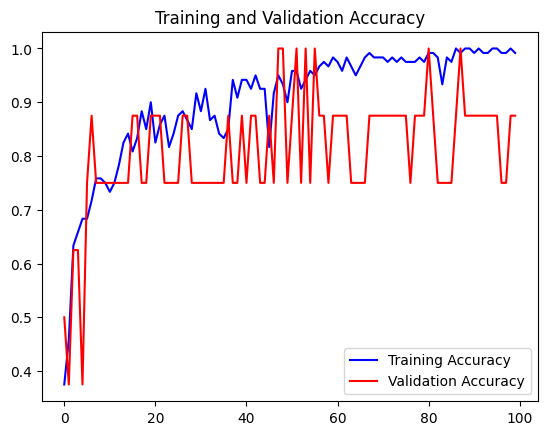

<Figure size 640x480 with 0 Axes>

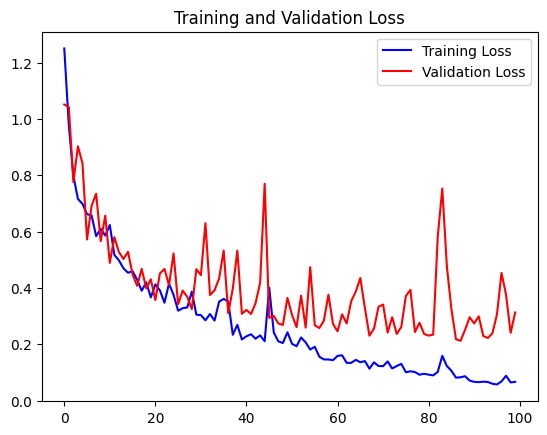

In [24]:
import matplotlib.pyplot as plt
epochs = range(len(train_acc))
plt.plot(epochs, train_acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.figure()
plt.show()

plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


**14. Evaluate model performance on test dataset**

In [25]:
test_output = model.evaluate(
    test_generator,
    steps=int(test_generator.samples / test_generator.batch_size),  # Convert steps to an integer
    verbose=1
)
print(test_output)
print(model.metrics_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step - accuracy: 0.6250 - loss: 1.3278
[1.327771544456482, 0.625]
['loss', 'compile_metrics']


References:

1. https://pypi.org/project/split-folders/
2. https://keras.io/